In [79]:
import pandas as pd
import os
folder = r"D:\documents projects\sales_intelligence &forecasting system\data"
print(os.listdir(folder))

['sample_-_superstore.xls']


In [80]:
file_path = os.path.join(folder, os.listdir(folder)[0])

print("Loading:", file_path)

df = pd.read_excel(
    file_path,
    engine="xlrd"
)

print("Dataset Shape:", df.shape)
display(df.head())

Loading: D:\documents projects\sales_intelligence &forecasting system\data\sample_-_superstore.xls
Dataset Shape: (10194, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [81]:
print(df.shape)
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

(10194, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State/Province               str
Postal Code               object
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object
Row I

In [82]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit
count,10194.000000,10194,10194,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,2025-04-29 11:48:25.002943,2025-05-03 10:52:45.626839,228.225854,3.791838,0.155385,28.673417
min,1.000000,2023-01-03 00:00:00,2023-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,2024-05-14 00:00:00,2024-05-19 00:00:00,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,2025-06-25 00:00:00,2025-06-28 00:00:00,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,2026-05-14 00:00:00,2026-05-18 00:00:00,209.500000,5.000000,0.200000,29.297925
max,10194.000000,2026-12-30 00:00:00,2027-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000
std,2942.898656,NaN,NaN,619.906839,2.228317,0.206249,232.465115


In [83]:
print("Order Date:")
print(df["Order Date"].head())

print("\nShip Date:")
print(df["Ship Date"].head())

print("\nData types:")
print(df[["Order Date", "Ship Date"]].dtypes)

Order Date:
0   2023-01-03
1   2023-01-04
2   2023-01-04
3   2023-01-04
4   2023-01-05
Name: Order Date, dtype: datetime64[us]

Ship Date:
0   2023-01-07
1   2023-01-08
2   2023-01-08
3   2023-01-08
4   2023-01-12
Name: Ship Date, dtype: datetime64[us]

Data types:
Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [84]:
print("Sales <= 0:", (df["Sales"] <= 0).sum())
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Discount < 0:", (df["Discount"] < 0).sum())
print("Discount > 1:", (df["Discount"] > 1).sum())

Sales <= 0: 0
Quantity <= 0: 0
Discount < 0: 0
Discount > 1: 0


In [85]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

shipping_days = (df["Ship Date"] - df["Order Date"]).dt.days

print(shipping_days.describe())
print("\nNegative shipping days:", (shipping_days < 0).sum())

count    10194.000000
mean         3.961350
std          1.742829
min          0.000000
25%          3.000000
50%          4.000000
75%          5.000000
max         11.000000
dtype: float64

Negative shipping days: 0


In [86]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (10194, 21)
Cleaned shape: (10194, 21)


In [87]:
print(df_clean.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


In [88]:
df_clean["Order Date"] = pd.to_datetime(df_clean["Order Date"])
df_clean["Ship Date"] = pd.to_datetime(df_clean["Ship Date"])

df_clean["Year"] = df_clean["Order Date"].dt.year
df_clean["Month"] = df_clean["Order Date"].dt.month
df_clean["Month_Name"] = df_clean["Order Date"].dt.month_name()
df_clean["Quarter"] = df_clean["Order Date"].dt.quarter
df_clean["Day_of_Week"] = df_clean["Order Date"].dt.day_name()
df_clean["Shipping_Days"] = (
    df_clean["Ship Date"] - df_clean["Order Date"]
).dt.days
df_clean["Profit_Margin"] = np.where(
    df_clean["Sales"] != 0,
    (df_clean["Profit"] / df_clean["Sales"]) * 100,
    np.nan
)
df_clean["Year_Month"] = (
    df_clean["Order Date"].dt.to_period("M").astype(str)
)

display(df_clean.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Discount,Profit,Year,Month,Month_Name,Quarter,Day_of_Week,Shipping_Days,Profit_Margin,Year_Month
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,0.2,5.5512,2023,1,January,1,Tuesday,4,33.75,2023-01
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,0.8,-5.4870,2023,1,January,1,Wednesday,4,-155.00,2023-01
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,0.2,4.2717,2023,1,January,1,Wednesday,4,36.25,2023-01
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,0.2,-64.7748,2023,1,January,1,Wednesday,4,-23.75,2023-01
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,0.2,4.8840,2023,1,January,1,Thursday,7,25.00,2023-01


# overall business KPI


In [89]:
total_sales = df_clean["Sales"].sum()
total_profit = df_clean["Profit"].sum()
total_quantity = df_clean["Quantity"].sum()
total_orders = df_clean["Order ID"].nunique()
total_customers = df_clean["Customer ID"].nunique()

profit_margin = (total_profit / total_sales) * 100

print("Total Sales       :", round(total_sales, 2))
print("Total Profit      :", round(total_profit, 2))
print("Total Quantity    :", total_quantity)
print("Total Orders      :", total_orders)
print("Total Customers   :", total_customers)
print("Profit Margin (%) :", round(profit_margin, 2))

Total Sales       : 2326534.35
Total Profit      : 292296.81
Total Quantity    : 38654
Total Orders      : 5111
Total Customers   : 804
Profit Margin (%) : 12.56


# category analysis 


In [90]:
category_analysis = (
    df_clean
    .groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

category_analysis

,Total_Sales,Total_Profit,Total_Quantity,Orders
Category,,,,
Technology,839893.2790,146543.3756,7017,1560
Furniture,754747.7613,19729.9956,8369,1819
Office Supplies,731893.3140,126023.4434,23268,3812


In [91]:
category_analysis["Profit_Margin_%"] = (
    category_analysis["Total_Profit"]
    / category_analysis["Total_Sales"]
) * 100

category_analysis

,Total_Sales,Total_Profit,Total_Quantity,Orders,Profit_Margin_%
Category,,,,,
Technology,839893.2790,146543.3756,7017,1560,17.447857
Furniture,754747.7613,19729.9956,8369,1819,2.614118
Office Supplies,731893.3140,126023.4434,23268,3812,17.218827


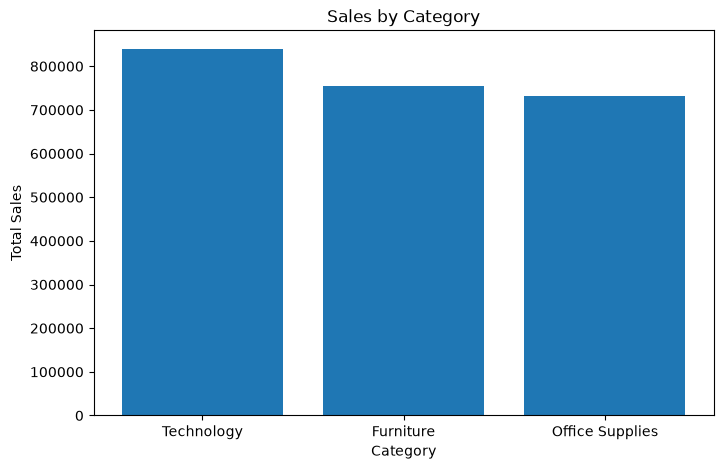

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis["Total_Sales"]
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

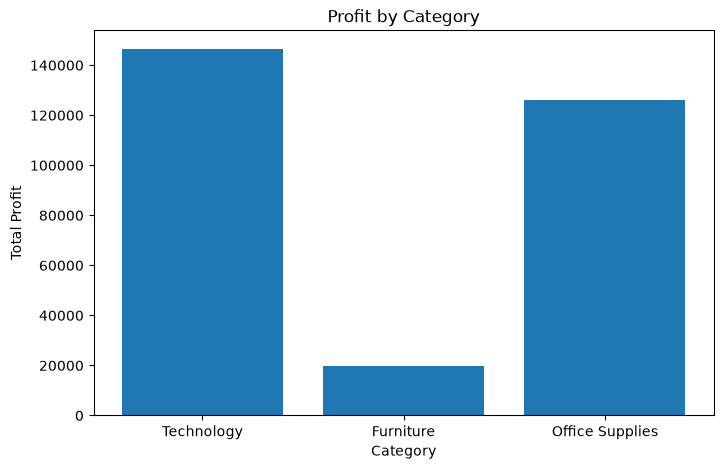

In [93]:
plt.figure(figsize=(8, 5))

plt.bar(
    category_analysis.index,
    category_analysis["Total_Profit"]
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

In [94]:
region_analysis = (
    df_clean
    .groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Customers=("Customer ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

region_analysis["Profit_Margin_%"] = (
    region_analysis["Total_Profit"]
    / region_analysis["Total_Sales"]
) * 100

region_analysis

,Total_Sales,Total_Profit,Orders,Customers,Profit_Margin_%
Region,,,,,
West,739813.6085,110798.8170,1635,686,14.976585
East,691828.1680,94883.2603,1475,685,13.714859
Central,503170.6728,39865.3070,1179,629,7.922820
South,391721.9050,46749.4303,822,512,11.934342


In [95]:
subcategory_analysis = (
    df_clean
    .groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Quantity=("Quantity", "sum")
    )
    .sort_values("Total_Sales", ascending=False)
)

subcategory_analysis["Profit_Margin_%"] = (
    subcategory_analysis["Total_Profit"]
    / subcategory_analysis["Total_Sales"]
) * 100

subcategory_analysis

,Total_Sales,Total_Profit,Quantity,Profit_Margin_%
Sub-Category,,,,
Chairs,335768.2490,27223.5323,2431,8.107834
Phones,331842.6400,45050.8265,3357,13.575961
Storage,224644.5540,21285.1115,3191,9.475018
Tables,208020.1820,-17753.2061,1261,-8.534367
Binders,207354.8810,31426.1003,6071,15.155708
Machines,189925.0310,3461.9769,442,1.822812
Accessories,167380.3180,41936.6357,2976,25.054700
Copiers,150745.2900,56093.9365,242,37.211071
Bookcases,115361.2043,-3632.0736,878,-3.148436


In [96]:
loss_making = subcategory_analysis[
    subcategory_analysis["Total_Profit"] < 0
]

loss_making

,Total_Sales,Total_Profit,Quantity,Profit_Margin_%
Sub-Category,,,,
Tables,208020.1820,-17753.2061,1261,-8.534367
Bookcases,115361.2043,-3632.0736,878,-3.148436
Supplies,46725.4980,-1171.3945,653,-2.506971


# monthly sale trend 


In [97]:
monthly_sales = (
    df_clean
    .groupby("Year_Month")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

monthly_sales.head()

,Year_Month,Sales,Profit
0,2023-01,14518.055,2539.3907
1,2023-02,4519.892,862.3084
2,2023-03,56933.909,693.4499
3,2023-04,28295.345,3488.8352
4,2023-05,26319.767,3196.3918


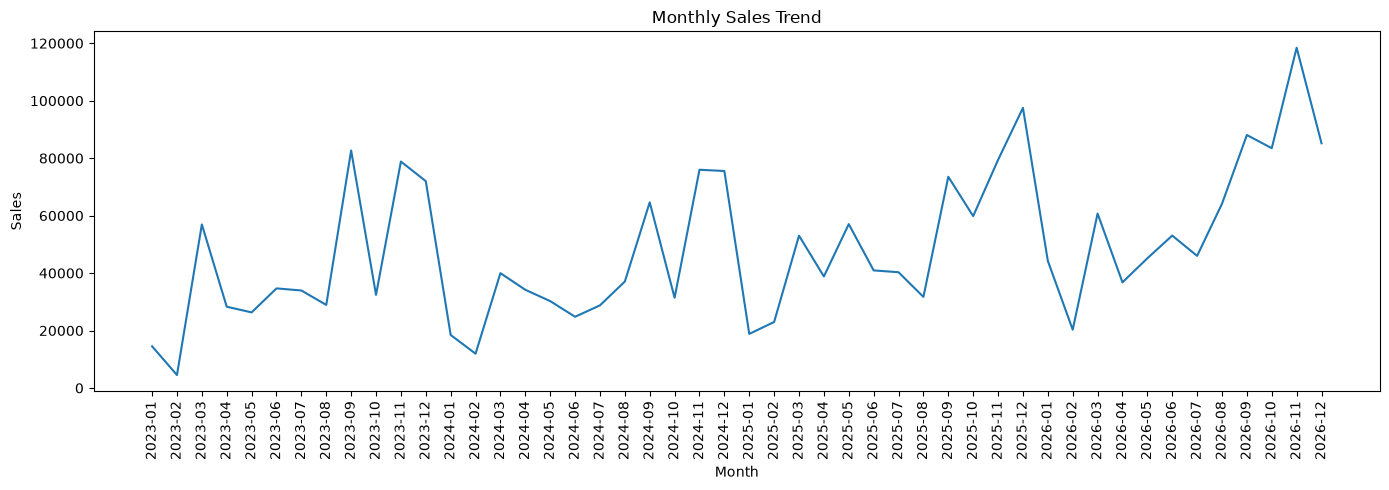

In [98]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["Year_Month"],
    monthly_sales["Sales"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# customer level analysis

In [99]:
customer_analysis = (
    df_clean
    .groupby(["Customer ID", "Customer Name"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Orders=("Order ID", "nunique"),
        Total_Quantity=("Quantity", "sum")
    )
    .reset_index()
)

customer_analysis["Profit_Margin_%"] = (
    customer_analysis["Total_Profit"]
    / customer_analysis["Total_Sales"]
) * 100

customer_analysis.head()

,Customer ID,Customer Name,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
0,AA-10315,Alex Avila,5563.560,-362.8825,5,30,-6.522487
1,AA-10375,Allen Armold,1056.390,277.3824,9,41,26.257575
2,AA-10480,Andrew Allen,1790.512,435.8274,4,36,24.340937
3,AA-10645,Anna Andreadi,5086.935,857.8033,6,64,16.862871
4,AB-10015,Aaron Bergman,886.156,129.3465,3,13,14.596358


In [100]:
top_customers_sales = (
    customer_analysis
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

top_customers_sales

,Customer ID,Customer Name,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
711,SM-20320,Sean Miller,25043.050,-1980.7393,5,50,-7.909337
752,TC-20980,Tamara Chand,19052.218,8981.3239,5,42,47.140569
632,RB-19360,Raymond Buch,15117.339,6976.0959,6,71,46.146322
741,TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36,32.227396
6,AB-10105,Adrian Barton,14473.571,5444.8055,10,73,37.618950
443,KL-16645,Ken Lonsdale,14175.229,806.8550,12,113,5.692007
680,SC-20095,Sanjit Chand,14142.334,5757.4119,9,87,40.710479
328,HL-15040,Hunter Lopez,12873.298,5622.4292,6,50,43.675127
694,SE-20110,Sanjit Engle,12209.438,2650.6769,11,78,21.710065
132,CC-12370,Christopher Conant,12129.072,2177.0493,5,34,17.949018


In [101]:
top_customers_profit = (
    customer_analysis
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_customers_profit

,Customer ID,Customer Name,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
752,TC-20980,Tamara Chand,19052.218,8981.3239,5,42,47.140569
632,RB-19360,Raymond Buch,15117.339,6976.0959,6,71,46.146322
680,SC-20095,Sanjit Chand,14142.334,5757.4119,9,87,40.710479
328,HL-15040,Hunter Lopez,12873.298,5622.4292,6,50,43.675127
6,AB-10105,Adrian Barton,14473.571,5444.8055,10,73,37.618950
741,TA-21385,Tom Ashbrook,14595.620,4703.7883,4,36,32.227396
161,CM-12385,Christopher Martinez,8954.020,3899.8904,4,34,43.554631
433,KD-16495,Keith Dawkins,8181.256,3038.6254,12,84,37.141307
48,AR-10540,Andy Reiter,6608.448,2884.6208,6,33,43.650503
235,DR-12940,Daniel Raglin,8350.868,2869.0760,8,57,34.356620


In [102]:
loss_customers = (
    customer_analysis[
        customer_analysis["Total_Profit"] < 0
    ]
    .sort_values("Total_Profit")
)

loss_customers.head(10)

,Customer ID,Customer Name,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
181,CS-12505,Cindy Stewart,5690.055,-6626.3895,6,40,-116.455632
311,GT-14635,Grant Thornton,9351.212,-4108.6589,3,26,-43.937181
468,LF-17185,Luke Foster,3930.509,-3583.9770,7,69,-91.183534
722,SR-20425,Sharelle Roach,3233.481,-3333.9144,5,34,-103.106046
323,HG-14965,Henry Goldwyn,3247.642,-2797.9635,12,68,-86.153692
565,NC-18415,Nathan Cano,2218.990,-2204.8072,6,38,-99.360844
677,SB-20290,Sean Braxton,8057.891,-2082.7451,7,84,-25.847273
711,SM-20320,Sean Miller,25043.050,-1980.7393,5,50,-7.909337
166,CP-12340,Christine Phan,5888.275,-1850.3029,8,59,-31.423514
571,NF-18385,Natalie Fritzler,8322.826,-1695.9714,7,52,-20.377350


In [103]:
reference_date = df_clean["Order Date"].max() + pd.Timedelta(days=1)

rfm = (
    df_clean
    .groupby(["Customer ID", "Customer Name"])
    .agg(
        Recency=("Order Date", lambda x:
                 (reference_date - x.max()).days),
        Frequency=("Order ID", "nunique"),
        Monetary=("Sales", "sum")
    )
    .reset_index()
)

rfm.head()

,Customer ID,Customer Name,Recency,Frequency,Monetary
0,AA-10315,Alex Avila,185,5,5563.560
1,AA-10375,Allen Armold,20,9,1056.390
2,AA-10480,Andrew Allen,260,4,1790.512
3,AA-10645,Anna Andreadi,56,6,5086.935
4,AB-10015,Aaron Bergman,416,3,886.156


In [104]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm.head()

,Customer ID,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,AA-10315,Alex Avila,185,5,5563.560,2,2,5
1,AA-10375,Allen Armold,20,9,1056.390,5,4,2
2,AA-10480,Andrew Allen,260,4,1790.512,1,1,3
3,AA-10645,Anna Andreadi,56,6,5086.935,3,3,5
4,AB-10015,Aaron Bergman,416,3,886.156,1,1,1


In [105]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
    + rfm["M_Score"].astype(str)
)

rfm["RFM_Total"] = (
    rfm["R_Score"]
    + rfm["F_Score"]
    + rfm["M_Score"]
)

rfm.head(10)

,Customer ID,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total
0,AA-10315,Alex Avila,185,5,5563.560,2,2,5,225,9
1,AA-10375,Allen Armold,20,9,1056.390,5,4,2,542,11
2,AA-10480,Andrew Allen,260,4,1790.512,1,1,3,113,5
3,AA-10645,Anna Andreadi,56,6,5086.935,3,3,5,335,11
4,AB-10015,Aaron Bergman,416,3,886.156,1,1,1,111,3
5,AB-10060,Adam Bellavance,55,8,7755.620,3,4,5,345,12
6,AB-10105,Adrian Barton,42,10,14473.571,4,5,5,455,14
7,AB-10150,Aimee Bixby,42,5,966.710,4,2,2,422,8
8,AB-10165,Alan Barnes,11,10,1215.022,5,5,2,552,12
9,AB-10255,Alejandro Ballentine,167,9,914.532,2,4,1,241,7


In [106]:
def segment_customer(row):

    if row["RFM_Total"] >= 13:
        return "High Value"

    elif row["RFM_Total"] >= 10:
        return "Loyal / Active"

    elif row["RFM_Total"] >= 7:
        return "Potential"

    elif row["RFM_Total"] >= 5:
        return "Needs Attention"

    else:
        return "Low Engagement"


rfm["Customer_Segment"] = rfm.apply(
    segment_customer,
    axis=1
)

rfm.head(10)

,Customer ID,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Customer_Segment
0,AA-10315,Alex Avila,185,5,5563.560,2,2,5,225,9,Potential
1,AA-10375,Allen Armold,20,9,1056.390,5,4,2,542,11,Loyal / Active
2,AA-10480,Andrew Allen,260,4,1790.512,1,1,3,113,5,Needs Attention
3,AA-10645,Anna Andreadi,56,6,5086.935,3,3,5,335,11,Loyal / Active
4,AB-10015,Aaron Bergman,416,3,886.156,1,1,1,111,3,Low Engagement
5,AB-10060,Adam Bellavance,55,8,7755.620,3,4,5,345,12,Loyal / Active
6,AB-10105,Adrian Barton,42,10,14473.571,4,5,5,455,14,High Value
7,AB-10150,Aimee Bixby,42,5,966.710,4,2,2,422,8,Potential
8,AB-10165,Alan Barnes,11,10,1215.022,5,5,2,552,12,Loyal / Active
9,AB-10255,Alejandro Ballentine,167,9,914.532,2,4,1,241,7,Potential


In [107]:
segment_summary = (
    rfm
    .groupby("Customer_Segment")
    .agg(
        Customers=("Customer ID", "count"),
        Total_Sales=("Monetary", "sum"),
        Avg_Sales=("Monetary", "mean")
    )
    .sort_values("Total_Sales", ascending=False)
)

segment_summary

,Customers,Total_Sales,Avg_Sales
Customer_Segment,,,
Loyal / Active,262,1.020583e+06,3895.356082
High Value,122,6.463301e+05,5297.787570
Potential,220,4.715928e+05,2143.603724
Needs Attention,119,1.396475e+05,1173.508709
Low Engagement,81,4.838062e+04,597.291623


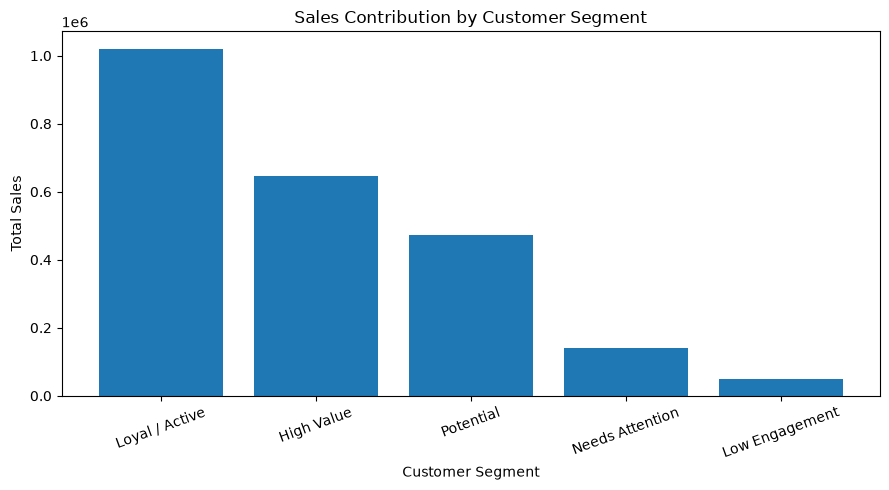

In [108]:
plt.figure(figsize=(9, 5))

plt.bar(
    segment_summary.index,
    segment_summary["Total_Sales"]
)

plt.title("Sales Contribution by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [109]:
customer_intelligence = rfm.merge(
    customer_analysis[
        [
            "Customer ID",
            "Total_Profit",
            "Total_Orders",
            "Total_Quantity",
            "Profit_Margin_%"
        ]
    ],
    on="Customer ID",
    how="left"
)

customer_intelligence.head()

,Customer ID,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Customer_Segment,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
0,AA-10315,Alex Avila,185,5,5563.560,2,2,5,225,9,Potential,-362.8825,5,30,-6.522487
1,AA-10375,Allen Armold,20,9,1056.390,5,4,2,542,11,Loyal / Active,277.3824,9,41,26.257575
2,AA-10480,Andrew Allen,260,4,1790.512,1,1,3,113,5,Needs Attention,435.8274,4,36,24.340937
3,AA-10645,Anna Andreadi,56,6,5086.935,3,3,5,335,11,Loyal / Active,857.8033,6,64,16.862871
4,AB-10015,Aaron Bergman,416,3,886.156,1,1,1,111,3,Low Engagement,129.3465,3,13,14.596358


In [110]:
high_sales_low_profit = (
    customer_intelligence[
        (customer_intelligence["Monetary"] >
         customer_intelligence["Monetary"].median())
        &
        (customer_intelligence["Total_Profit"] < 0)
    ]
    .sort_values("Monetary", ascending=False)
)

high_sales_low_profit.head(10)

,Customer ID,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Customer_Segment,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
711,SM-20320,Sean Miller,80,5,25043.050,3,2,5,325,10,Loyal / Active,-1980.7393,5,50,-7.909337
91,BM-11140,Becky Martin,308,4,11789.630,1,1,5,115,7,Potential,-1659.9581,4,64,-14.079815
311,GT-14635,Grant Thornton,57,3,9351.212,3,1,5,315,9,Potential,-4108.6589,3,26,-43.937181
599,PF-19120,Peter Fuller,835,4,9062.864,1,2,5,125,8,Potential,-614.2943,4,75,-6.778148
571,NF-18385,Natalie Fritzler,80,7,8322.826,3,4,5,345,12,Loyal / Active,-1695.9714,7,52,-20.377350
677,SB-20290,Sean Braxton,48,7,8057.891,4,4,5,445,13,High Value,-2082.7451,7,84,-25.847273
802,ZC-21910,Zuschuss Carroll,55,13,8025.707,3,5,5,355,13,High Value,-1032.1490,13,105,-12.860537
377,JH-15985,Joseph Holt,30,6,7954.998,4,3,5,435,12,Loyal / Active,-644.6982,6,64,-8.104316
345,JA-15970,Joseph Airdo,93,8,6491.026,3,4,5,345,12,Loyal / Active,-819.4217,8,87,-12.623916
797,VW-21775,Victoria Wilson,29,10,6134.038,4,5,5,455,14,High Value,-874.6645,10,77,-14.259196


# product analysis 


In [111]:
product_analysis = (
    df_clean
    .groupby(["Product ID", "Product Name", "Category", "Sub-Category"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Orders=("Order ID", "nunique"),
        Avg_Discount=("Discount", "mean")
    )
    .reset_index()
)

product_analysis["Profit_Margin_%"] = (
    product_analysis["Total_Profit"]
    / product_analysis["Total_Sales"]
) * 100

product_analysis.head()

,Product ID,Product Name,Category,Sub-Category,Total_Sales,Total_Profit,Total_Quantity,Orders,Avg_Discount,Profit_Margin_%
0,FUR-BO-10000112,"Bush Birmingham Collection Bookcase, Dark Cherry",Furniture,Bookcases,825.174,-117.8820,9,1,0.300000,-14.285714
1,FUR-BO-10000330,"Sauder Camden County Barrister Bookcase, Plank...",Furniture,Bookcases,1064.624,24.1960,10,3,0.100000,2.272727
2,FUR-BO-10000362,Sauder Inglewood Library Bookcases,Furniture,Bookcases,2154.348,311.1836,14,5,0.130000,14.444444
3,FUR-BO-10000468,O'Sullivan 2-Shelf Heavy-Duty Bookcases,Furniture,Bookcases,723.842,-133.1092,21,6,0.183333,-18.389262
4,FUR-BO-10000711,"Hon Metal Bookcases, Gray",Furniture,Bookcases,851.760,229.9752,12,2,0.000000,27.000000


In [112]:
top_products_sales = (
    product_analysis
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

top_products_sales

,Product ID,Product Name,Category,Sub-Category,Total_Sales,Total_Profit,Total_Quantity,Orders,Avg_Discount,Profit_Margin_%
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,2.519993e+04,20,5,0.120000,4.090909e+01
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27453.384,7.753039e+03,31,10,0.240000,2.824074e+01
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,-1.811078e+03,6,1,0.500000,-8.000000e+00
82,FUR-CH-10002024,HON 5400 Series Task Chairs for Big and Tall,Furniture,Chairs,21870.576,3.410605e-13,39,8,0.200000,1.559449e-15
701,OFF-BI-10001359,GBC DocuBind TL300 Electric Binding System,Office Supplies,Binders,19823.479,2.233505e+03,37,11,0.300000,1.126697e+01
667,OFF-BI-10000545,GBC Ibimaster 500 Manual ProClick Binding System,Office Supplies,Binders,19024.500,7.609800e+02,48,9,0.522222,4.000000e+00
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18839.686,6.983884e+03,38,8,0.200000,3.707006e+01
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,18374.895,4.094977e+03,12,3,0.166667,2.228571e+01
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,-1.878166e+03,27,6,0.450000,-1.045455e+01
1443,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,17030.312,-2.620048e+02,11,3,0.066667,-1.538462e+00


In [113]:
top_products_profit = (
    product_analysis
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_products_profit

,Product ID,Product Name,Category,Sub-Category,Total_Sales,Total_Profit,Total_Quantity,Orders,Avg_Discount,Profit_Margin_%
1640,TEC-CO-10004722,Canon imageCLASS 2200 Advanced Copier,Technology,Copiers,61599.824,25199.9280,20,5,0.120000,40.909091
787,OFF-BI-10003527,Fellowes PB500 Electric Punch Plastic Comb Bin...,Office Supplies,Binders,27453.384,7753.0390,31,10,0.240000,28.240741
1630,TEC-CO-10001449,Hewlett Packard LaserJet 3310 Copier,Technology,Copiers,18839.686,6983.8836,38,8,0.200000,37.070064
1637,TEC-CO-10003763,Canon PC1060 Personal Laser Copier,Technology,Copiers,11619.834,4570.9347,19,4,0.150000,39.337349
1657,TEC-MA-10001127,HP Designjet T520 Inkjet Large Format Printer ...,Technology,Machines,18374.895,4094.9766,12,3,0.166667,22.285714
1693,TEC-MA-10003979,Ativa V4110MDD Micro-Cut Shredder,Technology,Machines,7699.890,3772.9461,11,2,0.000000,49.000000
1656,TEC-MA-10001047,"3D Systems Cube Printer, 2nd Generation, Magenta",Technology,Machines,14299.890,3717.9714,11,2,0.000000,26.000000
1541,TEC-AC-10002049,Plantronics Savi W720 Multi-Device Wireless He...,Technology,Accessories,9367.290,3696.2820,24,7,0.057143,39.459459
692,OFF-BI-10001120,Ibico EPK-21 Electric Binding System,Office Supplies,Binders,15875.916,3345.2823,13,3,0.333333,21.071429
1643,TEC-MA-10000045,Zebra ZM400 Thermal Label Printer,Technology,Machines,6965.700,3343.5360,6,2,0.000000,48.000000


In [114]:
loss_making_products = (
    product_analysis[
        product_analysis["Total_Profit"] < 0
    ]
    .sort_values("Total_Profit")
)

loss_making_products.head(15)

,Product ID,Product Name,Category,Sub-Category,Total_Sales,Total_Profit,Total_Quantity,Orders,Avg_Discount,Profit_Margin_%
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.963,-8879.9704,9,3,0.533333,-80.000000
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.901,-4589.9730,18,4,0.400000,-27.272727
1696,TEC-MA-10004125,Cubify CubeX 3D Printer Triple Head Print,Technology,Machines,7999.980,-3839.9904,4,1,0.500000,-48.000000
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.640,-2876.1156,27,5,0.280000,-29.000000
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,9544.725,-1934.3976,33,7,0.350000,-20.266667
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.068,-1878.1662,27,6,0.450000,-10.454545
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.480,-1811.0784,6,1,0.500000,-8.000000
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.200,-1299.1836,22,6,0.100000,-7.800000
346,FUR-TA-10001950,Balt Solid Wood Round Tables,Furniture,Tables,6518.754,-1201.0581,19,4,0.200000,-18.424658
375,FUR-TA-10004289,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,Tables,1706.250,-1148.4375,15,3,0.483333,-67.307692


In [115]:
sales_threshold = product_analysis["Total_Sales"].quantile(0.75)

high_sales_low_profit = (
    product_analysis[
        (product_analysis["Total_Sales"] >= sales_threshold)
        &
        (product_analysis["Total_Profit"] < 0)
    ]
    .sort_values("Total_Sales", ascending=False)
)

high_sales_low_profit.head(15)

,Product ID,Product Name,Category,Sub-Category,Total_Sales,Total_Profit,Total_Quantity,Orders,Avg_Discount,Profit_Margin_%
1669,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.4800,-1811.0784,6,1,0.500000,-8.000000
858,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.0680,-1878.1662,27,6,0.450000,-10.454545
1443,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,17030.3120,-262.0048,11,3,0.066667,-1.538462
1650,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.9010,-4589.9730,18,4,0.400000,-27.272727
1465,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.2000,-1299.1836,22,6,0.100000,-7.800000
49,FUR-BO-10004834,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,15610.9656,-669.5448,24,5,0.234000,-4.288939
363,FUR-TA-10003473,Bretford Rectangular Conference Table Tops,Furniture,Tables,13565.5715,-359.3541,53,14,0.232143,-2.649016
1645,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.9630,-8879.9704,9,3,0.533333,-80.000000
326,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.6400,-2876.1156,27,5,0.280000,-29.000000
344,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,9544.7250,-1934.3976,33,7,0.350000,-20.266667


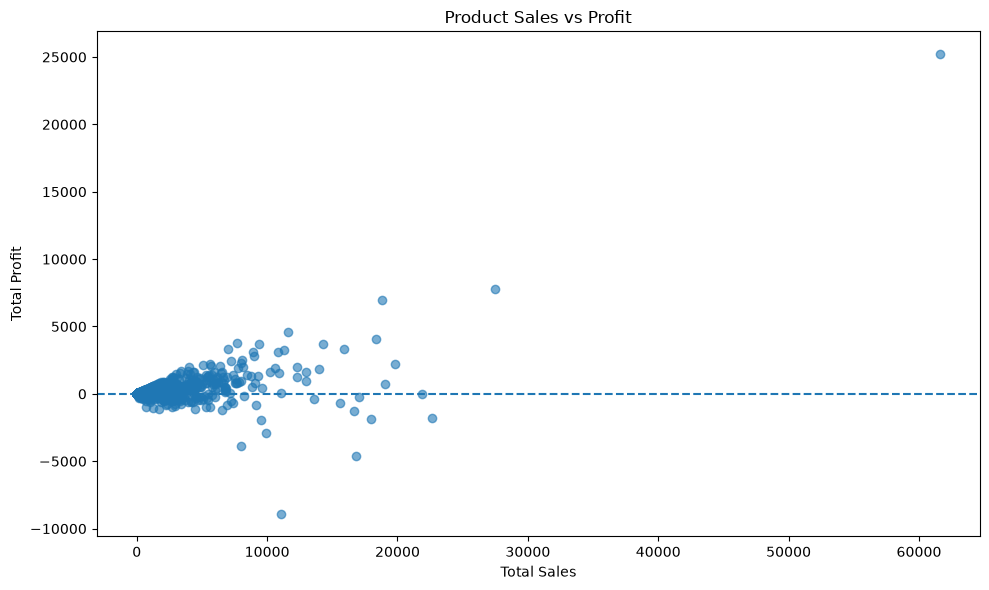

In [116]:
plt.figure(figsize=(10, 6))

plt.scatter(
    product_analysis["Total_Sales"],
    product_analysis["Total_Profit"],
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.title("Product Sales vs Profit")
plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

In [117]:
df_clean["Discount_Band"] = pd.cut(
    df_clean["Discount"],
    bins=[-0.01, 0, 0.10, 0.20, 0.30, 0.50, 1.00],
    labels=[
        "0%",
        "1-10%",
        "11-20%",
        "21-30%",
        "31-50%",
        "50%+"
    ]
)

In [118]:
discount_analysis = (
    df_clean
    .groupby("Discount_Band", observed=True)
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique"),
        Avg_Discount=("Discount", "mean")
    )
    .reset_index()
)

discount_analysis["Profit_Margin_%"] = (
    discount_analysis["Profit"]
    / discount_analysis["Sales"]
) * 100

discount_analysis

,Discount_Band,Sales,Profit,Orders,Avg_Discount,Profit_Margin_%
0,0%,1.105324e+06,326718.5872,2714,0.000000,29.558632
1,1-10%,5.495250e+04,9099.9700,91,0.100000,16.559702
2,11-20%,8.014979e+05,92498.9432,2469,0.199308,11.540759
3,21-30%,1.044741e+05,-10513.4456,214,0.300000,-10.063211
4,31-50%,1.953947e+05,-48477.0511,281,0.416045,-24.809805
5,50%+,6.489135e+04,-77030.1891,701,0.717391,-118.706402


# sql 

In [119]:
import sqlite3
conn = sqlite3.connect("sales_intelligence.db")

df_sql = df_clean.copy()

df_sql.to_sql(
    "sales",
    conn,
    if_exists="replace",
    index=False
)

print("SQL database created successfully!")
print("Table: sales")

SQL database created successfully!
Table: sales


In [120]:
query = """
SELECT *
FROM sales
LIMIT 5;
"""

sql_result = pd.read_sql_query(query, conn)

sql_result

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Profit,Year,Month,Month_Name,Quarter,Day_of_Week,Shipping_Days,Profit_Margin,Year_Month,Discount_Band
0,1,US-2023-103800,2023-01-03 00:00:00,2023-01-07 00:00:00,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,5.5512,2023,1,January,1,Tuesday,4,33.75,2023-01,11-20%
1,2,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,-5.4870,2023,1,January,1,Wednesday,4,-155.00,2023-01,50%+
2,3,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,4.2717,2023,1,January,1,Wednesday,4,36.25,2023-01,11-20%
3,4,US-2023-112326,2023-01-04 00:00:00,2023-01-08 00:00:00,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,-64.7748,2023,1,January,1,Wednesday,4,-23.75,2023-01,11-20%
4,5,US-2023-141817,2023-01-05 00:00:00,2023-01-12 00:00:00,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,4.8840,2023,1,January,1,Thursday,7,25.00,2023-01,11-20%


In [121]:
query = """
SELECT
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    SUM(Quantity) AS Total_Quantity,
    COUNT(DISTINCT "Order ID") AS Total_Orders,
    COUNT(DISTINCT "Customer ID") AS Total_Customers,
    ROUND(
        SUM(Profit) * 100.0 / SUM(Sales),
        2
    ) AS Profit_Margin_Percent
FROM sales;
"""

kpi_sql = pd.read_sql_query(query, conn)

kpi_sql

,Total_Sales,Total_Profit,Total_Quantity,Total_Orders,Total_Customers,Profit_Margin_Percent
0,2326534.35,292296.81,38654,5111,804,12.56


In [122]:
query = """
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(DISTINCT "Order ID") AS Orders,
    ROUND(
        SUM(Profit) * 100.0 / SUM(Sales),
        2
    ) AS Profit_Margin_Percent
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;
"""

region_sql = pd.read_sql_query(query, conn)

region_sql

,Region,Total_Sales,Total_Profit,Orders,Profit_Margin_Percent
0,West,739813.61,110798.82,1635,14.98
1,East,691828.17,94883.26,1475,13.71
2,Central,503170.67,39865.31,1179,7.92
3,South,391721.91,46749.43,822,11.93


In [123]:
query = """
SELECT
    "Sub-Category",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    SUM(Quantity) AS Total_Quantity,
    ROUND(
        SUM(Profit) * 100.0 / SUM(Sales),
        2
    ) AS Profit_Margin_Percent
FROM sales
GROUP BY "Sub-Category"
ORDER BY Total_Profit ASC;
"""

subcategory_sql = pd.read_sql_query(query, conn)

subcategory_sql

,Sub-Category,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_Percent
0,Tables,208020.18,-17753.21,1261,-8.53
1,Bookcases,115361.20,-3632.07,878,-3.15
2,Supplies,46725.50,-1171.39,653,-2.51
3,Fasteners,8532.24,2428.64,980,28.46
4,Machines,189925.03,3461.98,442,1.82
5,Labels,12695.04,5572.78,1410,43.90
6,Art,27659.01,6653.20,3092,24.05
7,Envelopes,16528.36,6988.02,914,42.28
8,Furnishings,95598.13,13891.74,3799,14.53
9,Appliances,108213.18,18329.48,1750,16.94


In [124]:
query = """
SELECT
    "Sub-Category",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(
        SUM(Profit) * 100.0 / SUM(Sales),
        2
    ) AS Profit_Margin_Percent
FROM sales
GROUP BY "Sub-Category"
HAVING SUM(Profit) < 0
ORDER BY Total_Profit ASC;
"""

loss_subcategories_sql = pd.read_sql_query(query, conn)

loss_subcategories_sql

,Sub-Category,Total_Sales,Total_Profit,Profit_Margin_Percent
0,Tables,208020.18,-17753.21,-8.53
1,Bookcases,115361.20,-3632.07,-3.15
2,Supplies,46725.50,-1171.39,-2.51


In [125]:
query = """
SELECT
    "Customer ID",
    "Customer Name",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(DISTINCT "Order ID") AS Orders
FROM sales
GROUP BY "Customer ID", "Customer Name"
ORDER BY Total_Sales DESC
LIMIT 10;
"""

top_customers_sql = pd.read_sql_query(query, conn)

top_customers_sql

,Customer ID,Customer Name,Total_Sales,Total_Profit,Orders
0,SM-20320,Sean Miller,25043.05,-1980.74,5
1,TC-20980,Tamara Chand,19052.22,8981.32,5
2,RB-19360,Raymond Buch,15117.34,6976.10,6
3,TA-21385,Tom Ashbrook,14595.62,4703.79,4
4,AB-10105,Adrian Barton,14473.57,5444.81,10
5,KL-16645,Ken Lonsdale,14175.23,806.85,12
6,SC-20095,Sanjit Chand,14142.33,5757.41,9
7,HL-15040,Hunter Lopez,12873.30,5622.43,6
8,SE-20110,Sanjit Engle,12209.44,2650.68,11
9,CC-12370,Christopher Conant,12129.07,2177.05,5


In [126]:
query = """
SELECT
    "Customer ID",
    "Customer Name",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(DISTINCT "Order ID") AS Orders
FROM sales
GROUP BY "Customer ID", "Customer Name"
HAVING SUM(Sales) > (
    SELECT AVG(Customer_Sales)
    FROM (
        SELECT SUM(Sales) AS Customer_Sales
        FROM sales
        GROUP BY "Customer ID"
    )
)
AND SUM(Profit) < 0
ORDER BY Total_Sales DESC;
"""

high_sales_loss_customers = pd.read_sql_query(
    query,
    conn
)

high_sales_loss_customers.head(10)

,Customer ID,Customer Name,Total_Sales,Total_Profit,Orders
0,SM-20320,Sean Miller,25043.05,-1980.74,5
1,BM-11140,Becky Martin,11789.63,-1659.96,4
2,GT-14635,Grant Thornton,9351.21,-4108.66,3
3,PF-19120,Peter Fuller,9062.86,-614.29,4
4,NF-18385,Natalie Fritzler,8322.83,-1695.97,7
5,SB-20290,Sean Braxton,8057.89,-2082.75,7
6,ZC-21910,Zuschuss Carroll,8025.71,-1032.15,13
7,JH-15985,Joseph Holt,7955.00,-644.70,6
8,JA-15970,Joseph Airdo,6491.03,-819.42,8
9,VW-21775,Victoria Wilson,6134.04,-874.66,10


In [127]:
query = """
SELECT
    CASE
        WHEN Discount = 0 THEN '0%'
        WHEN Discount <= 0.10 THEN '1-10%'
        WHEN Discount <= 0.20 THEN '11-20%'
        WHEN Discount <= 0.30 THEN '21-30%'
        WHEN Discount <= 0.50 THEN '31-50%'
        ELSE '50%+'
    END AS Discount_Band,

    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,

    ROUND(
        SUM(Profit) * 100.0 / SUM(Sales),
        2
    ) AS Profit_Margin_Percent

FROM sales

GROUP BY Discount_Band

ORDER BY
    MIN(Discount);
"""

discount_sql = pd.read_sql_query(query, conn)

discount_sql

,Discount_Band,Total_Sales,Total_Profit,Profit_Margin_Percent
0,0%,1105323.79,326718.59,29.56
1,1-10%,54952.50,9099.97,16.56
2,11-20%,801497.92,92498.94,11.54
3,21-30%,104474.07,-10513.45,-10.06
4,31-50%,195394.73,-48477.05,-24.81
5,50%+,64891.35,-77030.19,-118.71


In [128]:
query = """
SELECT
    "Product ID",
    "Product Name",
    Category,
    "Sub-Category",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    ROUND(AVG(Discount), 3) AS Avg_Discount
FROM sales

GROUP BY
    "Product ID",
    "Product Name",
    Category,
    "Sub-Category"

HAVING
    SUM(Profit) < 0

ORDER BY
    Total_Sales DESC

LIMIT 15;
"""

problem_products_sql = pd.read_sql_query(query, conn)

problem_products_sql

,Product ID,Product Name,Category,Sub-Category,Total_Sales,Total_Profit,Avg_Discount
0,TEC-MA-10002412,Cisco TelePresence System EX90 Videoconferenci...,Technology,Machines,22638.48,-1811.08,0.500
1,OFF-BI-10004995,GBC DocuBind P400 Electric Binding System,Office Supplies,Binders,17965.07,-1878.17,0.450
2,OFF-SU-10000151,High Speed Automatic Electric Letter Opener,Office Supplies,Supplies,17030.31,-262.00,0.067
3,TEC-MA-10000822,Lexmark MX611dhe Monochrome Laser Printer,Technology,Machines,16829.90,-4589.97,0.400
4,OFF-SU-10002881,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Supplies,16656.20,-1299.18,0.100
5,FUR-BO-10004834,"Riverside Palais Royal Lawyers Bookcase, Royal...",Furniture,Bookcases,15610.97,-669.54,0.234
6,FUR-TA-10003473,Bretford Rectangular Conference Table Tops,Furniture,Tables,13565.57,-359.35,0.232
7,TEC-MA-10000418,Cubify CubeX 3D Printer Double Head Print,Technology,Machines,11099.96,-8879.97,0.533
8,FUR-TA-10000198,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,Tables,9917.64,-2876.12,0.280
9,FUR-TA-10001889,Bush Advantage Collection Racetrack Conference...,Furniture,Tables,9544.72,-1934.40,0.350


# predictive modelling 

In [129]:
df_ml = df.copy()
df_ml["Order Date"] = pd.to_datetime(df_ml["Order Date"])
df_ml["Ship Date"] = pd.to_datetime(df_ml["Ship Date"])

df_ml["Shipping_Days"] = (
    df_ml["Ship Date"] - df_ml["Order Date"]
).dt.days

df_ml["Year"] = df_ml["Order Date"].dt.year
df_ml["Month"] = df_ml["Order Date"].dt.month
df_ml["Quarter"] = df_ml["Order Date"].dt.quarter
df_ml["Day_of_Week"] = df_ml["Order Date"].dt.day_name()
print("Dataset Shape:", df_ml.shape)

print("\nNew Features Created:")
print([
    "Shipping_Days",
    "Year",
    "Month",
    "Quarter",
    "Day_of_Week"
])

print("\nFirst 5 rows:")
display(
    df_ml[
        [
            "Order Date",
            "Ship Date",
            "Shipping_Days",
            "Year",
            "Month",
            "Quarter",
            "Day_of_Week"
        ]
    ].head()
)

Dataset Shape: (10194, 26)

New Features Created:
['Shipping_Days', 'Year', 'Month', 'Quarter', 'Day_of_Week']

First 5 rows:


,Order Date,Ship Date,Shipping_Days,Year,Month,Quarter,Day_of_Week
0,2023-01-03,2023-01-07,4,2023,1,1,Tuesday
1,2023-01-04,2023-01-08,4,2023,1,1,Wednesday
2,2023-01-04,2023-01-08,4,2023,1,1,Wednesday
3,2023-01-04,2023-01-08,4,2023,1,1,Wednesday
4,2023-01-05,2023-01-12,7,2023,1,1,Thursday


In [130]:
target = "Profit"
features = [
    "Sales",
    "Quantity",
    "Discount",
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Ship Mode",
    "Shipping_Days",
    "Year",
    "Month",
    "Quarter",
    "Day_of_Week"
]

missing_features = [
    col for col in features + [target]
    if col not in df_ml.columns
]

if missing_features:
    print("\n Missing columns:")
    print(missing_features)
else:
    print("\n All required columns are available.")
ml_df = df_ml[features + [target]].copy()

print("\nML Dataset Shape:", ml_df.shape)

print("\nML Dataset Columns:")
print(ml_df.columns.tolist())

print("\nFirst 5 rows:")
display(ml_df.head())


 All required columns are available.

ML Dataset Shape: (10194, 14)

ML Dataset Columns:
['Sales', 'Quantity', 'Discount', 'Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode', 'Shipping_Days', 'Year', 'Month', 'Quarter', 'Day_of_Week', 'Profit']

First 5 rows:


,Sales,Quantity,Discount,Category,Sub-Category,Segment,Region,Ship Mode,Shipping_Days,Year,Month,Quarter,Day_of_Week,Profit
0,16.448,2,0.2,Office Supplies,Paper,Consumer,Central,Standard Class,4,2023,1,1,Tuesday,5.5512
1,3.540,2,0.8,Office Supplies,Binders,Home Office,Central,Standard Class,4,2023,1,1,Wednesday,-5.4870
2,11.784,3,0.2,Office Supplies,Labels,Home Office,Central,Standard Class,4,2023,1,1,Wednesday,4.2717
3,272.736,3,0.2,Office Supplies,Storage,Home Office,Central,Standard Class,4,2023,1,1,Wednesday,-64.7748
4,19.536,3,0.2,Office Supplies,Art,Consumer,East,Standard Class,7,2023,1,1,Thursday,4.8840


In [131]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

X = ml_df.drop(columns=["Profit"])
y = ml_df["Profit"]


print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

numerical_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping_Days",
    "Year",
    "Month",
    "Quarter"
]

categorical_features = [
    "Category",
    "Sub-Category",
    "Segment",
    "Region",
    "Ship Mode",
    "Day_of_Week"
]


print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\nTrain/Test Split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("\nProcessed Data Shape:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed :", X_test_processed.shape)

Feature Shape: (10194, 13)
Target Shape: (10194,)

Numerical Features:
['Sales', 'Quantity', 'Discount', 'Shipping_Days', 'Year', 'Month', 'Quarter']

Categorical Features:
['Category', 'Sub-Category', 'Segment', 'Region', 'Ship Mode', 'Day_of_Week']

Train/Test Split:
X_train: (8155, 13)
X_test : (2039, 13)
y_train: (8155,)
y_test : (2039,)

Processed Data Shape:
X_train_processed: (8155, 45)
X_test_processed : (2039, 45)


In [132]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}
results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    
    model.fit(X_train_processed, y_train)

    
    y_pred = model.predict(X_test_processed)

    
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    })

    trained_models[name] = model
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)
display(results_df.round(4))

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,27.4813,133.4897,0.8014
1,Decision Tree,24.9612,138.7818,0.7853
2,Random Forest,21.3919,141.6090,0.7765
3,Linear Regression,61.7119,214.1379,0.4889


In [133]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.3.0


In [134]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

xgb_model.fit(
    X_train_processed,
    y_train
)

y_pred_xgb = xgb_model.predict(
    X_test_processed
)

xgb_mae = mean_absolute_error(
    y_test,
    y_pred_xgb
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_xgb
    )
)

xgb_r2 = r2_score(
    y_test,
    y_pred_xgb
)
print(f"MAE     : {xgb_mae:.4f}")
print(f"RMSE    : {xgb_rmse:.4f}")
print(f"R² Score: {xgb_r2:.4f}")
results_df.loc[len(results_df)] = [
    "XGBoost",
    xgb_mae,
    xgb_rmse,
    xgb_r2
]
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)
display(results_df.round(4))

Training XGBoost...
MAE     : 28.2165
RMSE    : 187.4472
R² Score: 0.6084


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,27.4813,133.4897,0.8014
1,Decision Tree,24.9612,138.7818,0.7853
2,Random Forest,21.3919,141.6090,0.7765
3,XGBoost,28.2165,187.4472,0.6084
4,Linear Regression,61.7119,214.1379,0.4889


In [135]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
param_grid = {
    "n_estimators": [200, 300, 500, 700, 900],
    "learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 10, 15],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.5],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [1, 10, 20, 40]
}
xgb_random = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring="r2",
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)
print("Starting XGBoost hyperparameter tuning...")

xgb_random.fit(
    X_train_processed,
    y_train
)
print("\n============================================")
print("BEST XGBOOST PARAMETERS")
print("============================================")

print(xgb_random.best_params_)
print("\nBest CV R² Score:")
print(round(xgb_random.best_score_, 4))

Starting XGBoost hyperparameter tuning...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

BEST XGBOOST PARAMETERS
{'subsample': 0.8, 'reg_lambda': 20, 'reg_alpha': 1, 'n_estimators': 700, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.08, 'gamma': 0, 'colsample_bytree': 0.9}

Best CV R² Score:
0.7668


In [136]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
best_xgb_model = xgb_random.best_estimator_
y_pred_tuned_xgb = best_xgb_model.predict(
    X_test_processed
)
tuned_xgb_mae = mean_absolute_error(
    y_test,
    y_pred_tuned_xgb
)

tuned_xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned_xgb
    )
)

tuned_xgb_r2 = r2_score(
    y_test,
    y_pred_tuned_xgb
)
print(f"MAE     : {tuned_xgb_mae:.4f}")
print(f"RMSE    : {tuned_xgb_rmse:.4f}")
print(f"R² Score: {tuned_xgb_r2:.4f}")
results_df.loc[len(results_df)] = [
    "Tuned XGBoost",
    tuned_xgb_mae,
    tuned_xgb_rmse,
    tuned_xgb_r2
]
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)
display(results_df.round(4))

MAE     : 27.3295
RMSE    : 188.5589
R² Score: 0.6037


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,27.4813,133.4897,0.8014
1,Decision Tree,24.9612,138.7818,0.7853
2,Random Forest,21.3919,141.6090,0.7765
3,XGBoost,28.2165,187.4472,0.6084
4,Tuned XGBoost,27.3295,188.5589,0.6037
5,Linear Regression,61.7119,214.1379,0.4889


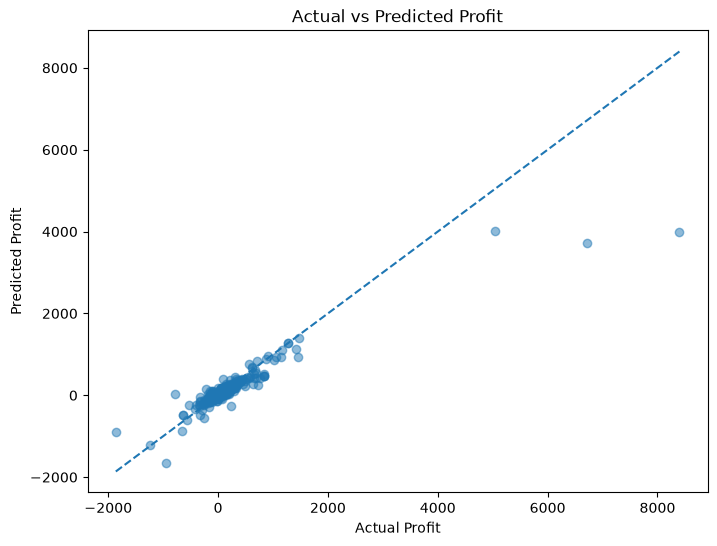

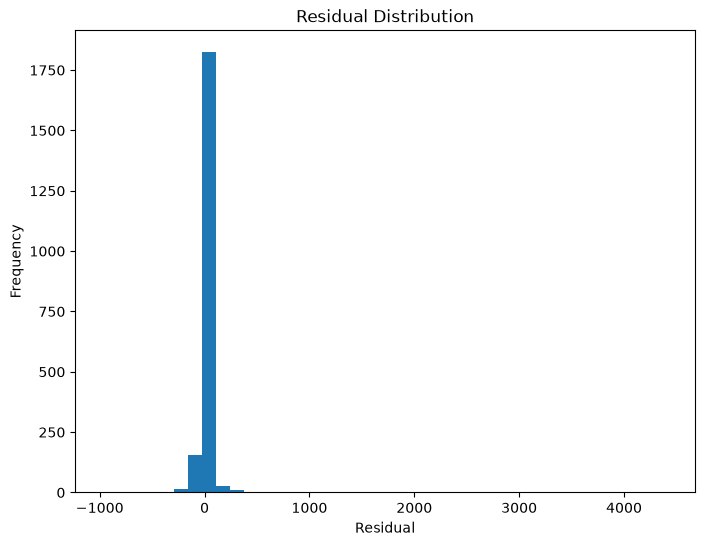

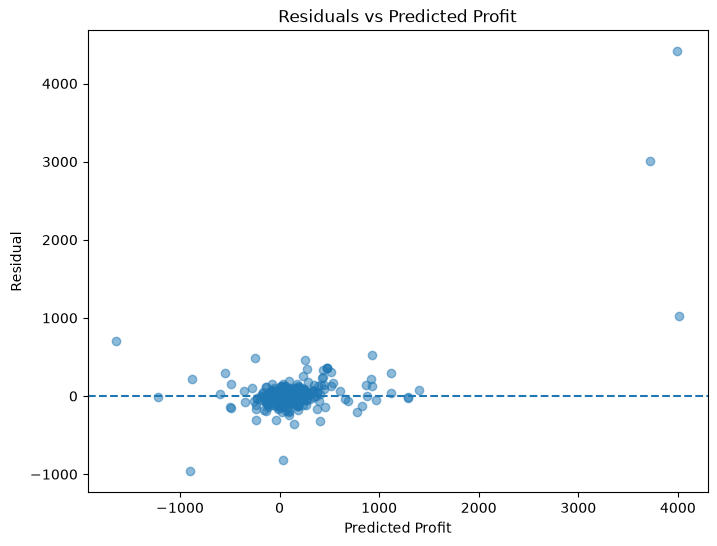

Mean Residual : 6.0555
Std Residual  : 133.3850
Min Residual  : -965.3106
Max Residual  : 4409.6839


In [137]:
import matplotlib.pyplot as plt
import numpy as np

best_model = trained_models["Gradient Boosting"]

y_pred_best = best_model.predict(
    X_test_processed
)
residuals = y_test - y_pred_best
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.5
)

min_value = min(y_test.min(), y_pred_best.min())
max_value = max(y_test.max(), y_pred_best.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Actual vs Predicted Profit")

plt.show()

plt.figure(figsize=(8, 6))

plt.hist(
    residuals,
    bins=40
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_best,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Profit")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Profit")

plt.show()
print(f"Mean Residual : {residuals.mean():.4f}")
print(f"Std Residual  : {residuals.std():.4f}")
print(f"Min Residual  : {residuals.min():.4f}")
print(f"Max Residual  : {residuals.max():.4f}")

In [138]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

y_train_pred = best_model.predict(
    X_train_processed
)

train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred
    )
)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_pred_best
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_best
    )
)

test_r2 = r2_score(
    y_test,
    y_pred_best
)
overfitting_df = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2 Score": [train_r2, test_r2]
})
display(overfitting_df.round(4))
r2_gap = train_r2 - test_r2

print(f"\nR² Gap (Train - Test): {r2_gap:.4f}")

,Dataset,MAE,RMSE,R2 Score
0,Training,20.7671,43.8021,0.9574
1,Testing,27.4813,133.4897,0.8014



R² Gap (Train - Test): 0.1560


In [139]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

gb_base = GradientBoostingRegressor(
    random_state=42
)

gb_param_grid = {
    "n_estimators": [100, 150, 200, 300, 400],
    "learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}
gb_random = RandomizedSearchCV(
    estimator=gb_base,
    param_distributions=gb_param_grid,
    n_iter=20,
    scoring="r2",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
print("Starting Gradient Boosting hyperparameter tuning...")

gb_random.fit(
    X_train_processed,
    y_train
)

print(gb_random.best_params_)
print("\nBest CV R² Score:")
print(round(gb_random.best_score_, 4))


Starting Gradient Boosting hyperparameter tuning...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 1, 'max_depth': 4, 'learning_rate': 0.1}

Best CV R² Score:
0.8099


In [140]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

best_gb_model = gb_random.best_estimator_

y_pred_tuned_gb = best_gb_model.predict(
    X_test_processed
)

tuned_gb_mae = mean_absolute_error(
    y_test,
    y_pred_tuned_gb
)

tuned_gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_tuned_gb
    )
)

tuned_gb_r2 = r2_score(
    y_test,
    y_pred_tuned_gb
)
print(f"MAE     : {tuned_gb_mae:.4f}")
print(f"RMSE    : {tuned_gb_rmse:.4f}")
print(f"R² Score: {tuned_gb_r2:.4f}")
results_df.loc[len(results_df)] = [
    "Tuned Gradient Boosting",
    tuned_gb_mae,
    tuned_gb_rmse,
    tuned_gb_r2
]
results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)
display(results_df.round(4))

MAE     : 21.6843
RMSE    : 156.3328
R² Score: 0.7276


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting,27.4813,133.4897,0.8014
1,Decision Tree,24.9612,138.7818,0.7853
2,Random Forest,21.3919,141.6090,0.7765
3,Tuned Gradient Boosting,21.6843,156.3328,0.7276
4,XGBoost,28.2165,187.4472,0.6084
5,Tuned XGBoost,27.3295,188.5589,0.6037
6,Linear Regression,61.7119,214.1379,0.4889


In [141]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))

print("\nFirst 20 processed features:")
print(feature_names[:20])

Number of processed features: 45

First 20 processed features:
['num__Sales' 'num__Quantity' 'num__Discount' 'num__Shipping_Days'
 'num__Year' 'num__Month' 'num__Quarter' 'cat__Category_Furniture'
 'cat__Category_Office Supplies' 'cat__Category_Technology'
 'cat__Sub-Category_Accessories' 'cat__Sub-Category_Appliances'
 'cat__Sub-Category_Art' 'cat__Sub-Category_Binders'
 'cat__Sub-Category_Bookcases' 'cat__Sub-Category_Chairs'
 'cat__Sub-Category_Copiers' 'cat__Sub-Category_Envelopes'
 'cat__Sub-Category_Fasteners' 'cat__Sub-Category_Furnishings']


,Feature,Importance
0,num__Sales,0.5657
1,num__Discount,0.3412
2,cat__Sub-Category_Binders,0.0152
3,cat__Sub-Category_Supplies,0.0146
4,cat__Sub-Category_Copiers,0.0141
5,cat__Sub-Category_Machines,0.0098
6,cat__Region_East,0.0087
7,cat__Region_West,0.0070
8,num__Quantity,0.0033
9,num__Shipping_Days,0.0031


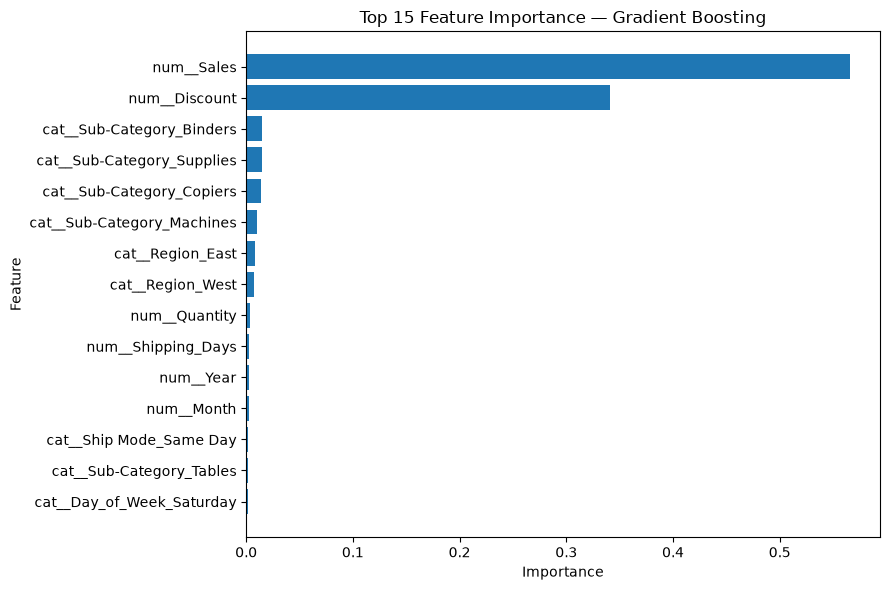

In [142]:
import pandas as pd
import matplotlib.pyplot as plt

importance_values = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)
display(
    feature_importance_df.head(15).round(4)
)
top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance — Gradient Boosting")

plt.tight_layout()
plt.show()

,Original_Feature,Importance
0,Sales,0.5657
1,Discount,0.3412
2,Sub-Category,0.0566
3,Region,0.0165
4,Quantity,0.0033
5,Shipping_Days,0.0031
6,Ship Mode,0.0030
7,Year,0.0024
8,Month,0.0023
9,Day_of_Week,0.0021


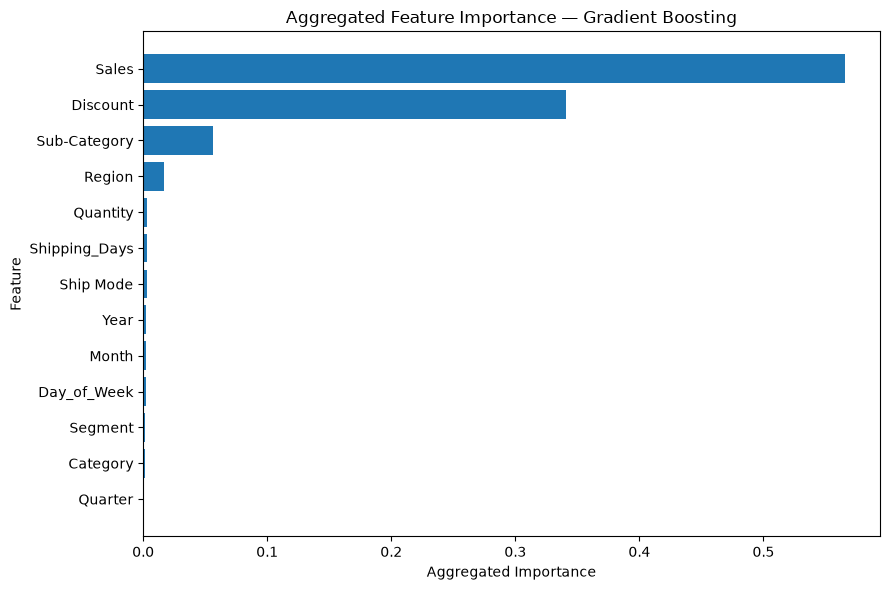

In [143]:
import pandas as pd
import matplotlib.pyplot as plt

agg_importance = feature_importance_df.copy()

def get_original_feature(feature):
    
    if feature.startswith("num__"):
        return feature.replace("num__", "")
    
    elif feature.startswith("cat__Category_"):
        return "Category"
    
    elif feature.startswith("cat__Sub-Category_"):
        return "Sub-Category"
    
    elif feature.startswith("cat__Segment_"):
        return "Segment"
    
    elif feature.startswith("cat__Region_"):
        return "Region"
    
    elif feature.startswith("cat__Ship Mode_"):
        return "Ship Mode"
    
    elif feature.startswith("cat__Day_of_Week_"):
        return "Day_of_Week"
    
    else:
        return feature

agg_importance["Original_Feature"] = (
    agg_importance["Feature"].apply(get_original_feature)
)
aggregated_importance = (
    agg_importance
    .groupby("Original_Feature")["Importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
display(
    aggregated_importance.round(4)
)
plot_data = aggregated_importance.sort_values(
    by="Importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_data["Original_Feature"],
    plot_data["Importance"]
)

plt.xlabel("Aggregated Importance")
plt.ylabel("Feature")
plt.title("Aggregated Feature Importance — Gradient Boosting")

plt.tight_layout()
plt.show()

,Feature,Importance_Mean,Importance_Std
0,Sales,1.3130,0.1236
1,Discount,0.8893,0.3815
2,Sub-Category,0.0615,0.0226
3,Category,0.0100,0.0020
4,Year,0.0001,0.0004
5,Region,-0.0000,0.0071
6,Ship Mode,-0.0000,0.0001
7,Shipping_Days,-0.0002,0.0004
8,Quarter,-0.0003,0.0021
9,Day_of_Week,-0.0004,0.0005


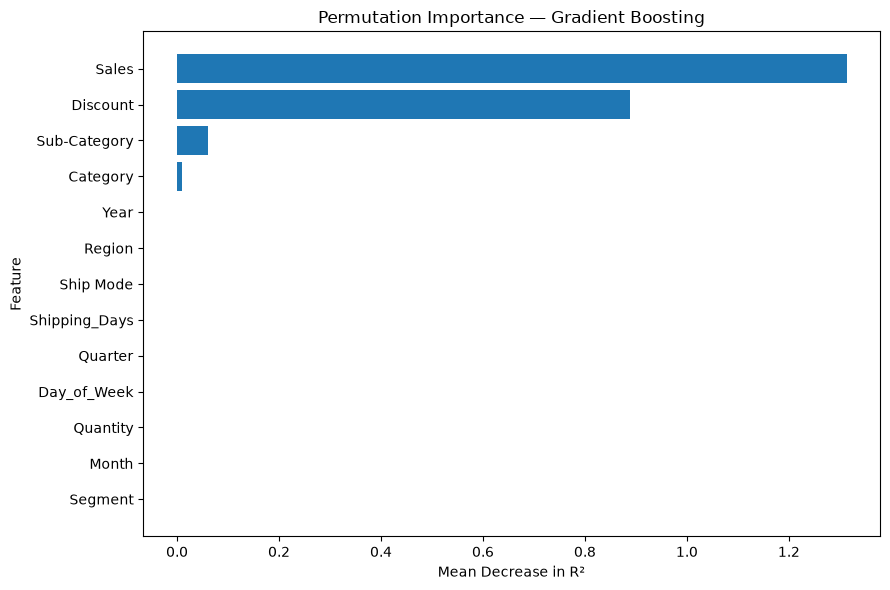

In [144]:
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

baseline_r2 = r2_score(
    y_test,
    best_model.predict(X_test_processed)
)

n_repeats = 10

permutation_results = []

for feature in X_test.columns:

    score_drops = []

    for i in range(n_repeats):

        X_test_permuted = X_test.copy()

        X_test_permuted[feature] = np.random.default_rng(
            42 + i
        ).permutation(
            X_test_permuted[feature].values
        )
        X_test_permuted_processed = preprocessor.transform(
            X_test_permuted
        )

        y_pred_permuted = best_model.predict(
            X_test_permuted_processed
        )

        permuted_r2 = r2_score(
            y_test,
            y_pred_permuted
        )
        score_drop = baseline_r2 - permuted_r2

        score_drops.append(score_drop)

    permutation_results.append({
        "Feature": feature,
        "Importance_Mean": np.mean(score_drops),
        "Importance_Std": np.std(score_drops)
    })
permutation_original_df = pd.DataFrame(
    permutation_results
)
permutation_original_df = (
    permutation_original_df
    .sort_values(
        by="Importance_Mean",
        ascending=False
    )
    .reset_index(drop=True)
)
display(
    permutation_original_df.round(4)
)
plot_perm = permutation_original_df.sort_values(
    by="Importance_Mean"
)

plt.figure(figsize=(9, 6))

plt.barh(
    plot_perm["Feature"],
    plot_perm["Importance_Mean"]
)

plt.xlabel("Mean Decrease in R²")
plt.ylabel("Feature")
plt.title("Permutation Importance — Gradient Boosting")

plt.tight_layout()
plt.show()

In [145]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd

final_model = best_model

final_predictions = final_model.predict(
    X_test_processed
)
final_mae = mean_absolute_error(
    y_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_test,
    final_predictions
)
final_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R² Score"
    ],
    "Value": [
        final_mae,
        final_rmse,
        final_r2
    ]
})
display(
    final_results.round(4)
)
prediction_comparison = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": final_predictions,
    "Error": y_test.values - final_predictions
})
display(
    prediction_comparison.head(15).round(2)
)

,Metric,Value
0,MAE,27.4813
1,RMSE,133.4897
2,R² Score,0.8014


,Actual Profit,Predicted Profit,Error
0,-14.33,-26.87,12.54
1,4.77,2.59,2.18
2,-7.71,-57.75,50.04
3,108.18,123.09,-14.92
4,218.25,211.56,6.69
5,585.55,446.71,138.84
6,48.96,47.19,1.77
7,20.68,20.55,0.14
8,1.79,12.07,-10.29
9,28.00,30.93,-2.93


In [146]:
import joblib
joblib.dump(
    final_model,
    "gradient_boosting_profit_model.pkl"
)
joblib.dump(
    preprocessor,
    "profit_preprocessor.pkl"
)
print("Saved:")
print("1. gradient_boosting_profit_model.pkl")
print("2. profit_preprocessor.pkl")

Saved:
1. gradient_boosting_profit_model.pkl
2. profit_preprocessor.pkl


In [147]:
import joblib
import numpy as np
loaded_model = joblib.load(
    "gradient_boosting_profit_model.pkl"
)

loaded_preprocessor = joblib.load(
    "profit_preprocessor.pkl"
)
X_test_loaded = loaded_preprocessor.transform(
    X_test
)
loaded_predictions = loaded_model.predict(
    X_test_loaded
)
prediction_difference = np.max(
    np.abs(
        final_predictions - loaded_predictions
    )
)


print("Original prediction :", final_predictions[0])
print("Reloaded prediction :", loaded_predictions[0])

print(
    "\nMaximum prediction difference:",
    prediction_difference
)
if prediction_difference < 1e-10:
    print("\n VERIFICATION PASSED")
    print("Saved model produces identical predictions.")
else:
    print("\n VERIFICATION CHECK REQUIRED")

Original prediction : -26.867784989476064
Reloaded prediction : -26.867784989476064

Maximum prediction difference: 0.0

 VERIFICATION PASSED
Saved model produces identical predictions.


In [76]:
print("Features expected by the model:")

for feature in X.columns:
    print("-", feature)

print("\nTotal input features:", len(X.columns))


Features expected by the model:
- Sales
- Quantity
- Discount
- Category
- Sub-Category
- Segment
- Region
- Ship Mode
- Shipping_Days
- Year
- Month
- Quarter
- Day_of_Week

Total input features: 13
